<a href="https://colab.research.google.com/github/arathykrishnatr-creator/DS-Lab-Programs/blob/main/PGM_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

dataset=pd.read_csv('/content/WineQT.csv')

In [ ]:
print("\nFirst five records")
print(dataset.head(5))

print("\nMissing values")
print(dataset.isnull().sum())

print("\nDescriptive statistics")
print(dataset.describe())


First five records
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8    

/tmp/ipykernel_2469/1852779395.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=dataset, palette='viridis')


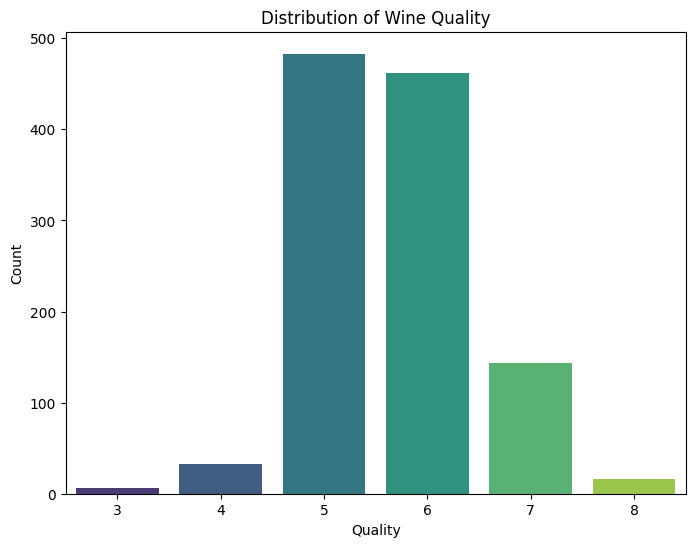

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=dataset, palette='viridis')
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()


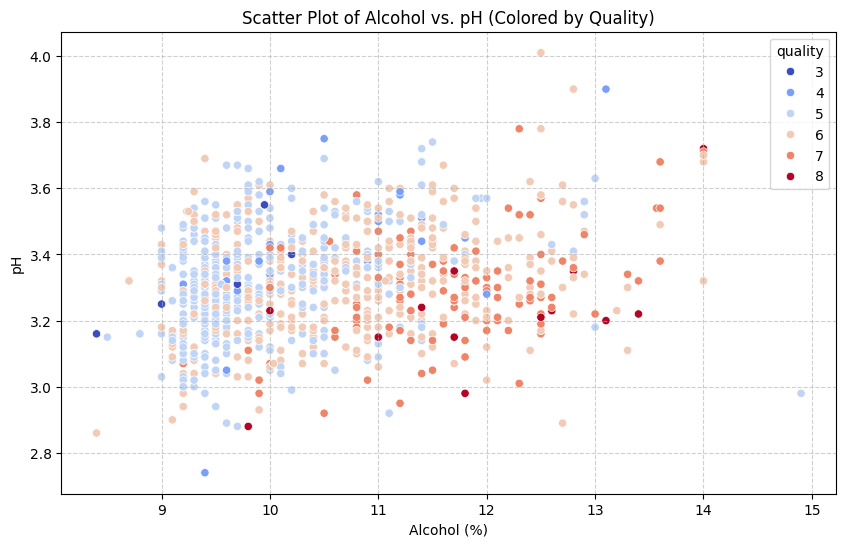

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='alcohol', y='pH', data=dataset, hue='quality', palette='coolwarm')
plt.title('Scatter Plot of Alcohol vs. pH (Colored by Quality)')
plt.xlabel('Alcohol (%)')
plt.ylabel('pH')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

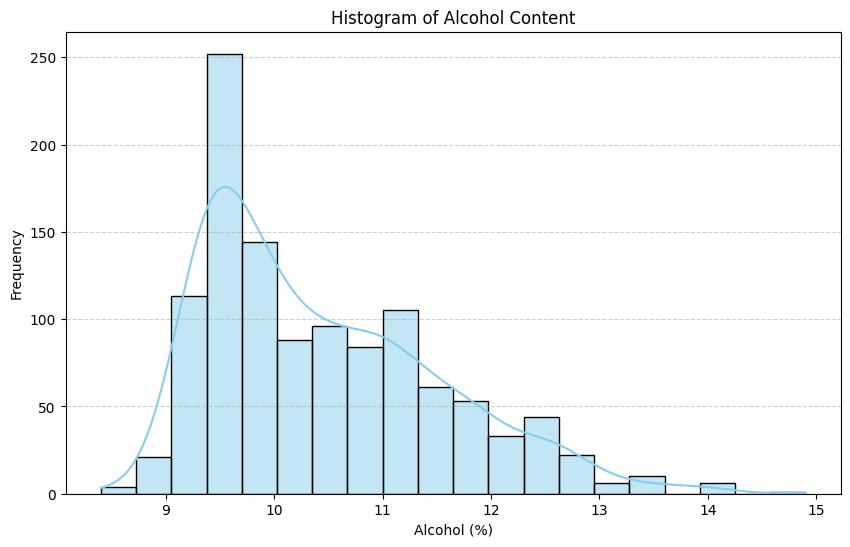

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(dataset['alcohol'], bins=20, kde=True, color='skyblue')
plt.title('Histogram of Alcohol Content')
plt.xlabel('Alcohol (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_2469/459098574.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alcohol', data=dataset, palette='viridis')


Text(0, 0.5, 'Alcohol (%)')

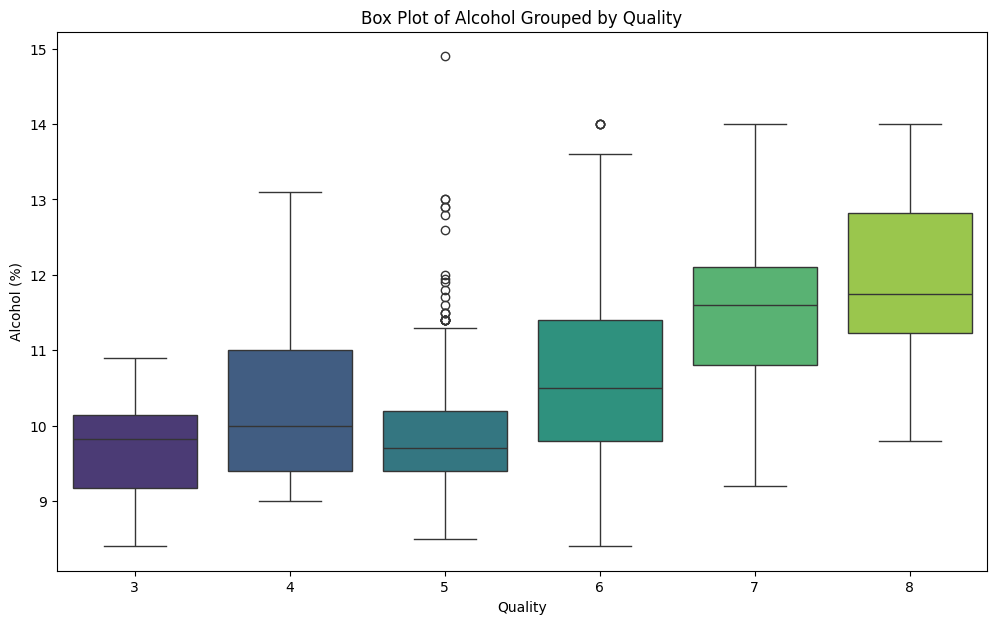

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='quality', y='alcohol', data=dataset, palette='viridis')
plt.title('Box Plot of Alcohol Grouped by Quality')
plt.xlabel('Quality')
plt.ylabel('Alcohol (%)')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (914, 11)
X_test shape: (229, 11)
y_train shape: (914,)
y_test shape: (229,)


In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features standardized.")

Features standardized.


k = 3: Accuracy = 0.6070
k = 5: Accuracy = 0.5764
k = 7: Accuracy = 0.5939
k = 9: Accuracy = 0.6201
k = 11: Accuracy = 0.6288


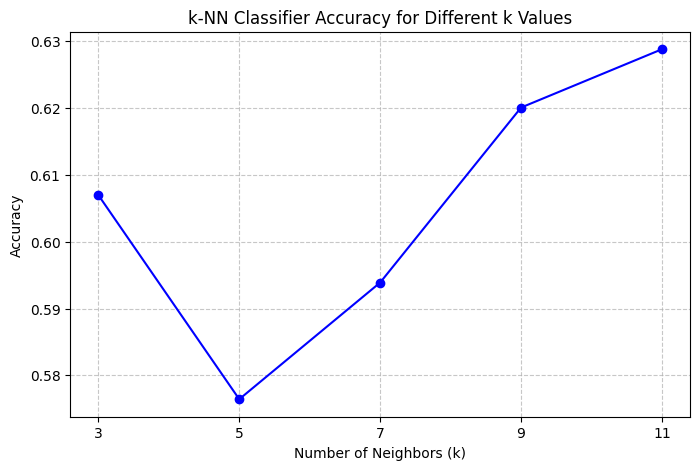

In [ ]:

k_values = [3, 5, 7, 9, 11]
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"k = {k}: Accuracy = {accuracy:.4f}")
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='blue')
plt.title('k-NN Classifier Accuracy for Different k Values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:

k_input_values = [1, 2, 6, 10]
for k in k_input_values:
    if k < 1:
        print(f"k must be a positive integer. Skipping k = {k}")
        continue
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Using user-specified k = {k}: Accuracy = {accuracy:.4f}")

Using user-specified k = 1: Accuracy = 0.6507
Using user-specified k = 2: Accuracy = 0.6026
Using user-specified k = 6: Accuracy = 0.5808
Using user-specified k = 10: Accuracy = 0.6245
